### Regresión Lineal Múltiple - Predicción de Glucemia en Población Pima

Utilizaremos el dataset PimaIndiansDiabetes2 del paquete mlbench. Este estudio clásico permite analizar predictores fisiológicos de la diabetes. Modelaremos la glucose (glucosa plasmática a las 2 horas) en función del bmi (Índice de Masa Corporal) y la age (edad).

### Análisis Exploratorio (EDA)

Es fundamental verificar la correlación entre predictores para evitar problemas de multicolinealidad.

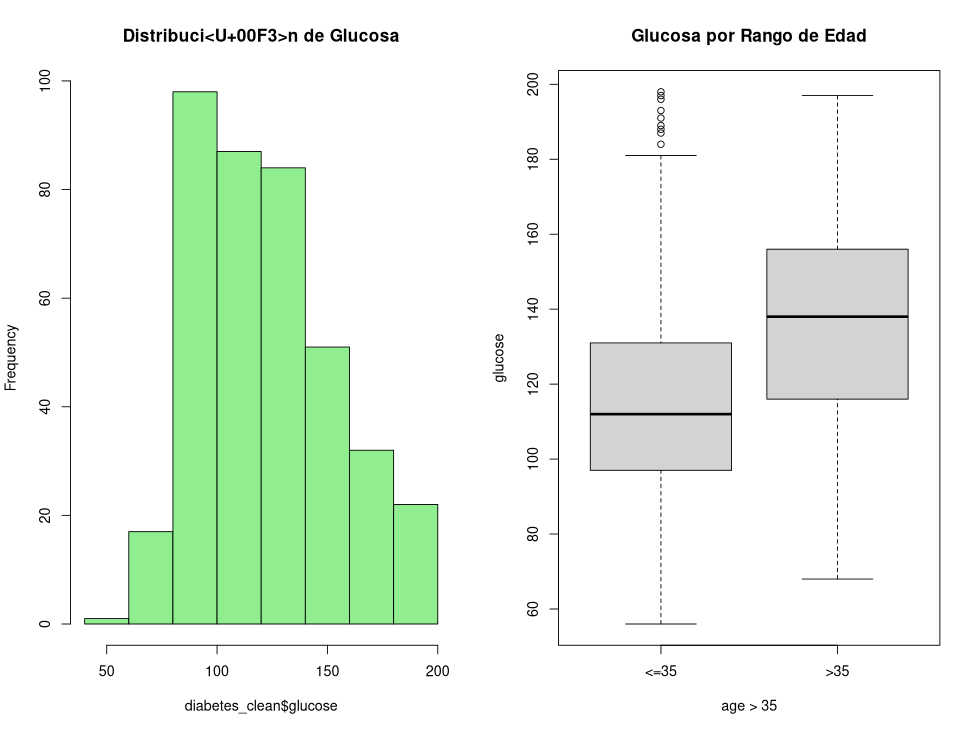

          glucose      mass       age
glucose 1.0000000 0.2095159 0.3436415
mass    0.2095159 1.0000000 0.0698138
age     0.3436415 0.0698138 1.0000000

In [3]:
library(mlbench)
data("PimaIndiansDiabetes2")
diabetes_clean <- na.omit(PimaIndiansDiabetes2)

# confirm column names
names(diabetes_clean)

# correlation matrix (use 'mass' for BMI)
cor_matrix <- cor(diabetes_clean[, c("glucose", "mass", "age")])

# plots
par(mfrow = c(1, 2))
hist(diabetes_clean$glucose, col = "lightgreen", main = "Distribución de Glucosa")
boxplot(glucose ~ age > 35, data = diabetes_clean,
        main = "Glucosa por Rango de Edad", names = c("<=35", ">35"))

# return correlation matrix
cor_matrix

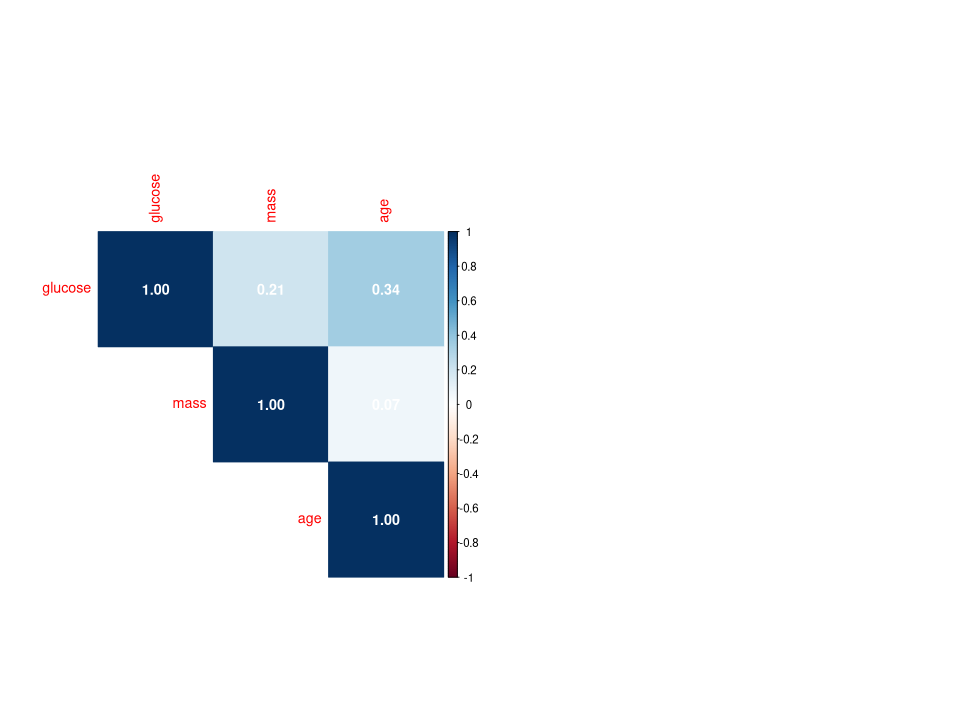

In [6]:
# Visualize correlation matrix as heatmap
library(corrplot)
corrplot(cor_matrix, method = "color", type = "upper", 
         addCoef.col = "white", diag = TRUE)

In [7]:
# Show correlation matrix with numeric values
print(cor_matrix)

          glucose      mass       age
glucose 1.0000000 0.2095159 0.3436415
mass    0.2095159 1.0000000 0.0698138
age     0.3436415 0.0698138 1.0000000


In [8]:
# Find the strongest correlation pairs (excluding diagonal)
cor_matrix[upper.tri(cor_matrix)] |> sort(decreasing = TRUE) |> head(3)

[1] 0.3436415 0.2095159 0.0698138

Modelamiento